In [68]:
import numpy as np 
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

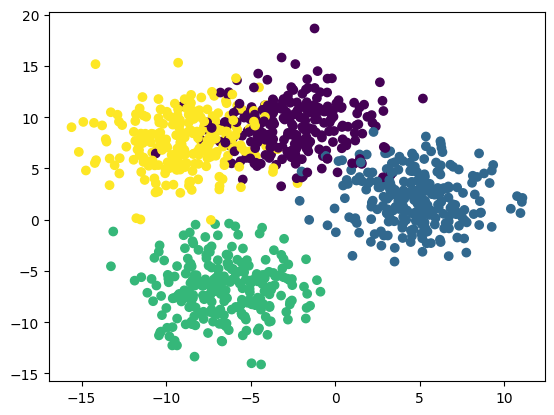

In [69]:
df = make_blobs(n_samples=1000, n_features=2, centers=4 , cluster_std=2.5, random_state=42)

X = df[0]
y = df[1]
plt.scatter(X[:,0], X[:,1], c=y)

In [70]:
p = int(len(X)*0.75)
X_train, y_train = X[0:p], y[0:p]
X_test, y_test = X[p:], y[p:]

print(X_train.shape, y_train.shape, X_test.shape , y_test.shape)

(750, 2) (750,) (250, 2) (250,)


In [71]:
X_train

array([[-8.13010808,  6.67626048],
       [-5.02438876, -6.13187814],
       [-5.48380991, -6.69009611],
       ...,
       [-6.50795855, -7.72282452],
       [-4.64164414, -5.29218009],
       [-7.18199756, -5.83127848]])

In [72]:
distances = np.argsort(np.linalg.norm((X_test[:,None] - X_train), axis=2), axis=1)

neighbors = distances[:, 0:3]
votes = y_train[neighbors[:, 0:4]]
np.bincount(y_train[neighbors[200, 0:4]])


array([0, 0, 3], dtype=int64)

In [73]:
class KNN():
    def __init__(self, k):
        self.k = k
        
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        
    def predict(self, X_test):
        distances = np.argsort(np.linalg.norm((X_test[:,None] - self.X_train), axis=2), axis=1)
        neighbors = distances[:, 0:self.k]
        votes = self.y_train[neighbors[:, 0:self.k]]
        preds = np.array([
            np.argmax(np.bincount(row))
            for row in votes
        ])

        return preds


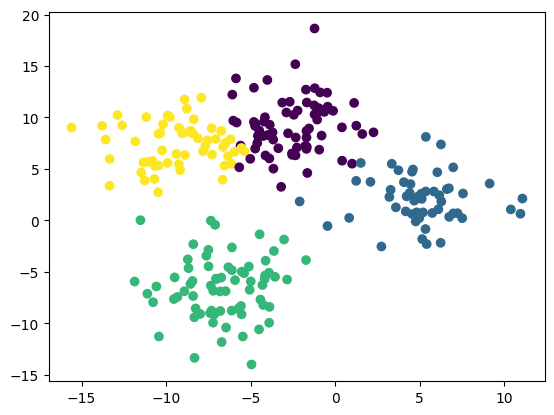

In [80]:
model = KNN(k=10)
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_test)